
## 1. Descripción General

- **Objetivo:**  
  Copiar desde el directorio de imágenes redimensionadas hacia una estructura de carpetas `classification_dataV4-test/{train,val,test}/{NORMAL,VIRAL,BACTERIAL}`.

- **Clases finales:**  
  - NORMAL  
  - VIRAL (imágenes que en el nombre contienen “virus”)  
  - BACTERIAL (imágenes que en el nombre contienen “bact”)


In [17]:
import shutil
from pathlib import Path

# Ruta original
SRC = Path("/workspace/data/redimensionadas")
# Ruta destino
DST = Path("/workspace/data/classification_dataV4-test")
splits = ["train", "val", "test"]

for split in splits:
    for cls in ["NORMAL", "VIRAL", "BACTERIAL"]:
        (DST/split/cls).mkdir(parents=True, exist_ok=True)

    # Copiar NORMAL
    for img in (SRC/split/"NORMAL").iterdir():
        shutil.copy(img, DST/split/"NORMAL"/img.name)

    # De PNEUMONIA extraer por nombre
    for img in (SRC/split/"PNEUMONIA").iterdir():
        name = img.stem.lower()
        if "virus" in name:
            target = "VIRAL"
        elif "bact" in name:
            target = "BACTERIAL"
        else:
            continue
        shutil.copy(img, DST/split/target/img.name)


## 2. Fine-tuning y Generación Sintética con GAN

### 2.1 Objetivo
- **Siempre Retomar** un GAN (Generator + Discriminator) ya entrenado hasta cierta época.
- **Añadir** `MORE_EPOCHS` de entrenamiento extra (fine-tuning).
- **Generar** imágenes sintéticas por clase hasta emparejar el tamaño máximo (`max_count`) y lograr un dataset balanceado.

El objetivo es mejorar su capacidad para crear radiografías de tórax sintéticas de tres clases ―**NORMAL**, **VIRAL** y **BACTERIAL**― y, después, usar ese generador para equilibrar el número de ejemplos por categoría dentro del conjunto de entrenamiento.


###  Configuración inicial
- **Resolución** de salida: **224 × 224 px** en escala de grises (`CHANNELS = 1`).  
- **Vector ruido**: `LATENT_DIM = 100`.  
- **Clases**: `["NORMAL", "VIRAL", "BACTERIAL"]`.  
- **Tamaño de lote**: `BATCH_SIZE = 16`.  
- **Épocas extra**: `MORE_EPOCHS = 200`.  
- **Rutas clave**:  
  - `TRAIN_DIR` → carpeta de imágenes reales de entrenamiento.  
  - `CKPT_DIR`  → carpeta para guardar / restaurar checkpoints.

---

###  Arquitectura
- **Generator**  
  - Entrada: vector de ruido + etiqueta de clase (Embedding).  
  - Pila de *Conv2DTranspose* con *BatchNorm* y *LeakyReLU*.  
  - Bloque de **Self-Attention** en resolución 14 × 14.  
  - Salida: imagen 224 × 224 × 1 con activación `tanh`.

- **Discriminator**  
  - Concatena la imagen (real o sintética) con un mapa que codifica la clase.  
  - Varias *Conv2D* con **Spectral Normalization** y *LeakyReLU*.  
  - Capa densa final → logit autenticidad.

- **Pérdidas**: _Hinge loss_ para ambos modelos.  
- **Optimización**: TTUR (Adam 1e-4 para G, 4e-4 para D, `β₁ = 0.5`).

---

###  Flujo de entrenamiento
1. **Preparar dataset**  
   - Leer JPEG → convertir a tensor, redimensionar, normalizar a \[-1, 1\].  
   - Mezclar, agrupar en lotes y pre-cargar con `tf.data`.

2. **Restaurar checkpoint** (si existe)  
   - Detectar la última época entrenada.  
   - Reducir las tasas de aprendizaje al 50 % para comenzar _fine-tuning_.

3. **Bucle de épocas** (`start_epoch` → `end_epoch`)  
   - Por lote:  
     - Añadir 📉 **ruido Gaussiano** muy leve a la imagen real (estabilidad).  
     - Calcular y aplicar gradientes para Generador y Discriminador.  
   - Cada 10 épocas (o la última): guardar nuevo checkpoint numerado.

---

###  Generación sintética y balanceo
- Calcular **conteo real** de imágenes por clase.  
- Determinar cuántas faltan para igualar a la clase mayoritaria (`max_count`).  
- Para cada muestra faltante:  
  1. Muestrear vector de ruido + etiqueta fija.  
  2. Generar imagen con el Generador _congelado_.  
  3. Re-escalar \[-1, 1\] → \[0, 255\] y guardar como JPEG en la carpeta de su clase.

- Resultado final: **todas las clases tienen exactamente `max_count` imágenes**.

---



In [10]:
import os
import re
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import save_img
from pathlib import Path

# ----------------------------------------
# 1) Parámetros y rutas
# ----------------------------------------
IMG_HEIGHT = 224
IMG_WIDTH  = 224
CHANNELS   = 1
LATENT_DIM = 100
CLASSES    = ["NORMAL", "VIRAL", "BACTERIAL"]
BATCH_SIZE = 16


MORE_EPOCHS = 200

TRAIN_DIR = Path("/workspace/data/classification_dataV4-test/train")
CKPT_DIR  = Path("/workspace/checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

# ----------------------------------------
# 2) Definición de Generator y Discriminator
# ----------------------------------------
def build_generator():
    noise = layers.Input((LATENT_DIM,))
    label = layers.Input((1,), dtype='int32')
    emb   = layers.Embedding(len(CLASSES), LATENT_DIM)(label)
    emb   = layers.Flatten()(emb)
    x     = layers.multiply([noise, emb])
    x     = layers.Dense(7*7*512, use_bias=False)(x)
    x     = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x     = layers.Reshape((7,7,512))(x)

    # Upsample 7→14
    x = layers.Conv2DTranspose(256, (5,5), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # Self-Attention sobre 14×14
    h, w, c = 14, 14, 256
    x_ = layers.Reshape((h*w, c))(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=c//4)(x_, x_)
    x   = layers.Reshape((h, w, c))(attn)

    # Upsamples 14→28→56→112→224
    for filt in [128, 64, 32, 16]:
        x = layers.Conv2DTranspose(filt, (5,5), strides=2, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    img = layers.Conv2D(CHANNELS, (7,7), activation='tanh', padding='same')(x)
    return Model([noise, label], img, name="generator")

def build_discriminator():
    img   = layers.Input((IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    label = layers.Input((1,), dtype='int32')
    emb   = layers.Embedding(len(CLASSES), IMG_HEIGHT*IMG_WIDTH)(label)
    emb   = layers.Reshape((IMG_HEIGHT, IMG_WIDTH, 1))(emb)
    x     = layers.Concatenate()([img, emb])
    for filt in [16, 32, 64, 128]:
        x = tfa.layers.SpectralNormalization(
                layers.Conv2D(filt, (5,5), strides=2, padding='same')
            )(x)
        x = layers.LeakyReLU(0.2)(x); x = layers.Dropout(0.3)(x)
    x   = layers.Flatten()(x)
    out = tfa.layers.SpectralNormalization(layers.Dense(1))(x)
    return Model([img, label], out, name="discriminator")

# Hinge losses
def d_hinge(real, fake):
    return tf.reduce_mean(tf.nn.relu(1.-real)) + tf.reduce_mean(tf.nn.relu(1.+fake))
def g_hinge(fake):
    return -tf.reduce_mean(fake)

# ----------------------------------------
# 3) Instancia modelos y optimizadores (TTUR)
# ----------------------------------------
generator     = build_generator()
discriminator = build_discriminator()
gen_opt  = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(4e-4, beta_1=0.5)

# Checkpoint
ckpt = tf.train.Checkpoint(
    gen=generator, gen_opt=gen_opt,
    disc=discriminator, disc_opt=disc_opt
)
manager = tf.train.CheckpointManager(ckpt, CKPT_DIR, max_to_keep=5)

# ----------------------------------------
# 4) Paso de entrenamiento
# ----------------------------------------
@tf.function
def train_step(real_images, real_labels):
    real_noisy = tf.clip_by_value(
        real_images + tf.random.normal(tf.shape(real_images), 0., 0.01),
        -1., 1.
    )
    bs         = tf.shape(real_images)[0]
    noise      = tf.random.normal([bs, LATENT_DIM])
    rnd_labels = tf.random.uniform([bs,1], maxval=len(CLASSES), dtype=tf.int32)
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = generator([noise, rnd_labels], training=True)
        r_log = discriminator([real_noisy, real_labels], training=True)
        f_log = discriminator([fake, rnd_labels], training=True)
        g_loss = g_hinge(f_log)
        d_loss = d_hinge(r_log, f_log)
    grads_g = gt.gradient(g_loss, generator.trainable_variables)
    grads_d = dt.gradient(d_loss, discriminator.trainable_variables)
    gen_opt.apply_gradients(zip(grads_g, generator.trainable_variables))
    disc_opt.apply_gradients(zip(grads_d, discriminator.trainable_variables))
    return g_loss, d_loss

# ----------------------------------------
# 5) Dataset con tf.data
# ----------------------------------------
def load_ds():
    paths, labels = [], []
    for i,cls in enumerate(CLASSES):
        for p in (TRAIN_DIR/cls).glob("*"):
            paths.append(str(p)); labels.append(i)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def parse(p, l):
        img = tf.image.decode_jpeg(tf.io.read_file(p), channels=1)
        img = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))
        img = (img - 127.5) / 127.5
        return img, tf.reshape(l, (1,))
    return ds.map(parse, tf.data.AUTOTUNE)\
             .shuffle(1000).batch(BATCH_SIZE)\
             .prefetch(tf.data.AUTOTUNE)

train_ds = load_ds()

# ----------------------------------------
# 6) Restaurar último checkpoint y reajustar LR
# ----------------------------------------
start_epoch = 1
if manager.latest_checkpoint:
    ckpt.restore(manager.latest_checkpoint)
    m = re.search(r"ckpt-(\d+)", manager.latest_checkpoint)
    if m:
        last = int(m.group(1))
        start_epoch = last + 1
    # Reducir learning-rate al retomar
    gen_opt.lr.assign(gen_opt.lr * 0.5)
    disc_opt.lr.assign(disc_opt.lr * 0.5)
    print(f"✅ Restaurado {manager.latest_checkpoint}, reanudar en época {start_epoch}")
    print("🎯 Nuevos LR:", gen_opt.lr.numpy(), disc_opt.lr.numpy())

# ----------------------------------------
# 7) Entrenamiento adicional
# ----------------------------------------
end_epoch = start_epoch + MORE_EPOCHS - 1
for epoch in range(start_epoch, end_epoch + 1):
    for imgs, lbls in train_ds:
        gl, dl = train_step(imgs, lbls)
    if epoch % 10 == 0 or epoch == end_epoch:
        manager.save(checkpoint_number=epoch)
        print(f"Epoch {epoch}/{end_epoch} ▶ gen_loss={gl:.4f}, disc_loss={dl:.4f} ▶ checkpoint saved")

# ----------------------------------------
# 8) Generación final para balanceo
# ----------------------------------------
counts    = {c: len(list((TRAIN_DIR/c).glob("*"))) for c in CLASSES}
max_count = max(counts.values())
for idx, cls in enumerate(CLASSES):
    to_gen = max_count - counts[cls]
    print(f"{cls}: {counts[cls]} reales → generando {to_gen}")
    for i in range(to_gen):
        noise = tf.random.normal([1, LATENT_DIM])
        lab   = tf.constant([[idx]], dtype=tf.int32)
        img   = generator([noise, lab], training=False)
        arr   = (img[0] * 127.5 + 127.5).numpy().astype("uint8")
        arr   = arr.reshape(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
        save_img(str(TRAIN_DIR/cls/f"{cls}_gen_{i+1:04d}.jpeg"), arr, scale=False)

print("✔ Balanceo completado: cada clase tiene", max_count, "imágenes.")


✅ Restaurado /workspace/checkpoints/ckpt-400, fine-tune desde ep 401
🎯 Nuevos LR: 5e-05 0.0002


2025-07-13 21:00:21.054232: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype int32 and shape [5144]
	 [[{{node Placeholder/_1}}]]
2025-07-13 21:00:21.054673: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5144]
	 [[{{node Placeholder/_0}}]]
2025-07-13 21:00:23.069367: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator/dropout_16/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-07-13 21:00:41.027347: E tensorflow/

Epoch 410: gen_loss=0.6291, disc_loss=0.9571 ▶ checkpoint guardado
Epoch 420: gen_loss=0.9347, disc_loss=0.8151 ▶ checkpoint guardado
Epoch 430: gen_loss=0.0907, disc_loss=0.9923 ▶ checkpoint guardado
Epoch 440: gen_loss=0.4409, disc_loss=0.7478 ▶ checkpoint guardado
Epoch 450: gen_loss=0.3940, disc_loss=0.9876 ▶ checkpoint guardado
Epoch 460: gen_loss=0.7003, disc_loss=0.8189 ▶ checkpoint guardado
Epoch 470: gen_loss=0.3520, disc_loss=0.7675 ▶ checkpoint guardado
Epoch 480: gen_loss=0.7015, disc_loss=1.0630 ▶ checkpoint guardado
Epoch 490: gen_loss=0.4152, disc_loss=0.7980 ▶ checkpoint guardado
Epoch 500: gen_loss=-0.2366, disc_loss=1.8520 ▶ checkpoint guardado
Epoch 510: gen_loss=0.0624, disc_loss=0.9872 ▶ checkpoint guardado
Epoch 520: gen_loss=0.7289, disc_loss=0.6498 ▶ checkpoint guardado
Epoch 530: gen_loss=0.0088, disc_loss=1.4264 ▶ checkpoint guardado
Epoch 540: gen_loss=0.1090, disc_loss=1.2526 ▶ checkpoint guardado
Epoch 550: gen_loss=0.2228, disc_loss=1.3318 ▶ checkpoint gua

## 3. Modelo ImageNet

### Configuración inicial
- **Estructura de carpetas**  
  - `BASE_DIR/train` → entrenamiento  
  - `BASE_DIR/val`   → validación  
  - `BASE_DIR/test`  → prueba
- **Dimensiones**: 224 × 224 px, 3 canales (RGB).  
- **Batch size**: 32.  
- **Optimización**: Adam `1e-4` (fase 1) → `1e-5` (fase 2).  
- **Callbacks**:  
  - *EarlyStopping* (paciencia = 5, restaura mejor checkpoint)  
  - *ReduceLROnPlateau* (factor 0.5, paciencia = 3)  
  - *ModelCheckpoint* (`best_vgg16.h5`, guarda cuando sube `val_accuracy`)

---

###  Balance de clases
- Se contabilizan imágenes por clase en `TRAIN_DIR`.  
- Se calcula `class_weight` = *(tamaño de la clase mayor / tamaño de cada clase)* para mitigar el desbalance durante el entrenamiento.

---

###  Generación de datos
- **Entrenamiento**:  
  - Reescalado 1/255  
  - Aumentos: rotación ±15°, traslación 10 %, zoom 10 %, _flip_ horizontal, brillo (0.8–1.2), _shear_ 5 %, relleno *nearest*.  
- **Validación & Test**: solo reescalado 1/255.  
- Los *ImageDataGenerator* producen lotes etiquetados en modo _categorical_.

---

###  Modelo
- **Base**: `VGG16(weights="imagenet", include_top=False)` congelada inicialmente.  
- **Cabeza**:  
  1. `Flatten`  
  2. `Dense(256, relu)`  
  3. `Dropout(0.5)`  
  4. `Dense(n_clases, softmax)`  

---

###  Entrenamiento
1. **Fase 1 – Solo la cabeza**  
   - Épocas: 15  
   - `base.trainable = False`  
   - Ponderación de clases aplicada.  
2. **Fase 2 – Fine-tuning**  
   - Se descongelan las **4 últimas capas convolucionales** de VGG-16.  
   - LR reducido a `1e-5`.  
   - Épocas: 10 adicionales.  
   - Misma estrategia de *callbacks* y *class_weight*.

### Conclusiones
- El modelo alcanza **87 % de precisión** en el conjunto de prueba, mostrando alto _recall_ para **BACTERIAL** y **VIRAL**, y excelente precisión para **NORMAL**.  
- En validación, la clase **VIRAL** es minoritaria (sin ejemplos), lo que explica la falta de métricas.
- El archivo `vgg16_finetuned_entrega.h5` contiene los pesos óptimos listos para inferencia o despliegue.

In [3]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# 1) Rutas
BASE_DIR = "/workspace/data/classification_dataV4-4-test"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# 2) Contar ejemplos por clase para class_weight
classes = sorted(os.listdir(TRAIN_DIR))
counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
max_count = max(counts.values())
class_weight = {i: max_count / counts[cls] for i, cls in enumerate(classes)}

# 3) Generadores de imágenes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    shear_range=0.05,
    fill_mode="nearest"
)
valtest_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)
val_gen = valtest_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
test_gen = valtest_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# 4) Modelo con VGG16
base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False   # congelar toda la base

model = Sequential([
    base,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(classes), activation="softmax")
])

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# 5) Callbacks
cbs = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ModelCheckpoint("best_vgg16.h5", monitor="val_accuracy", save_best_only=True)
]

# 6) Entrenamiento fase 1 (solo cabeza)
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=cbs
)

# 7) Fine‑tuning: descongelar últimas 4 capas convolucionales
base.trainable = True
for layer in base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=cbs
)

# 8) Evaluación final en Test
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest accuracy: {acc*100:.2f}%")

# 9) Classification report y matriz de confusión
#   Necesitamos etiquetas y predicciones en crudo
test_gen.reset()
y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


2025-07-15 23:50:03.385197: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 7590 images belonging to 3 classes.
Found 16 images belonging to 3 classes.
Found 624 images belonging to 3 classes.


2025-07-15 23:50:05.426323: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.444154: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.444446: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.446313: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.446576: I tensorflow/compile

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 256)               6422784   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                 771       
                                                                 
Total params: 21,138,243
Trainable params: 6,423,555
Non-trainable params: 14,714,688
_________________________________________________________________
Epoch 1/15


2025-07-15 23:50:07.123674: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-07-15 23:50:07.751837: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-07-15 23:50:08.753685: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-07-15 23:50:08.798896: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7a8d2804ef10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-15 23:50:08.798940: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-07-15 23:50:08.80

...

238/238 [==============================] - 38s 155ms/step - loss: 0.4053 - accuracy: 0.8281 - val_loss: 0.7949 - val_accuracy: 0.6875 - lr: 1.0000e-05
Epoch 2/10
238/238 [==============================] - 37s 157ms/step - loss: 0.3641 - accuracy: 0.8440 - val_loss: 0.6778 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 3/10
238/238 [==============================] - 38s 157ms/step - loss: 0.3497 - accuracy: 0.8531 - val_loss: 0.7895 - val_accuracy: 0.5625 - lr: 1.0000e-05
Epoch 4/10
238/238 [==============================] - 38s 158ms/step - loss: 0.3353 - accuracy: 0.8568 - val_loss: 0.7625 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 5/10
238/238 [==============================] - 37s 157ms/step - loss: 0.3224 - accuracy: 0.8582 - val_loss: 0.8939 - val_accuracy: 0.6250 - lr: 1.0000e-05
Epoch 6/10
238/238 [==============================] - 38s 158ms/step - loss: 0.3153 - accuracy: 0.8639 - val_loss: 0.5378 - val_accuracy: 0.7500 - lr: 5.0000e-06
Epoch 7/10
 2/20 [==>..................

2025-07-15 23:58:58.611243: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


20/20 [==============================] - 1s 70ms/step - loss: 0.4814 - accuracy: 0.8718

Test accuracy: 87.18%


2025-07-15 23:59:00.083796: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.87      0.97      0.92       242
      NORMAL       0.95      0.79      0.87       234
       VIRAL       0.78      0.84      0.81       148

    accuracy                           0.87       624
   macro avg       0.87      0.87      0.86       624
weighted avg       0.88      0.87      0.87       624

Confusion Matrix:
[[234   8   0]
 [ 12 186  36]
 [ 22   2 124]]


In [5]:
# 10) Guardar el modelo nuevamente para exportación
model.save("vgg16_finetuned_entrega.h5")
print("Modelo guardado en vgg16_finetuned.h5")

# — Guardar en el formato TensorFlow SavedModel —
model.save("vgg16_savedmodel_entrega", save_format="tf")
print("Modelo guardado en la carpeta 'vgg16_savedmodel'")


Modelo guardado en vgg16_finetuned.h5


2025-07-15 23:59:22.332624: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,256]
	 [[{{node inputs}}]]
2025-07-15 23:59:22.602288: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,256]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: vgg16_savedmodel_entrega/assets


INFO:tensorflow:Assets written to: vgg16_savedmodel_entrega/assets


Modelo guardado en la carpeta 'vgg16_savedmodel'


In [4]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Si aún no lo tienes, extrae los nombres de clase desde tu generador de train:
classes = list(train_gen.class_indices.keys())

# 1) Evaluar accuracy sobre validación
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation accuracy: {val_acc*100:.2f}%")

# 2) Reporte de clasificación y matriz de confusión
val_gen.reset()
y_val_true = val_gen.classes
y_val_prob = model.predict(val_gen, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)

print("\nValidation Classification Report:")
print(classification_report(
    y_val_true, 
    y_val_pred, 
    target_names=classes
))

print("Validation Confusion Matrix:")
print(confusion_matrix(y_val_true, y_val_pred))


2025-07-15 23:59:13.261010: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


1/1 [==============================] - 0s 308ms/step - loss: 0.6778 - accuracy: 0.7500

Validation accuracy: 75.00%

Validation Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       1.00      0.50      0.67         8
      NORMAL       0.89      1.00      0.94         8
       VIRAL       0.00      0.00      0.00         0

    accuracy                           0.75        16
   macro avg       0.63      0.50      0.54        16
weighted avg       0.94      0.75      0.80        16

Validation Confusion Matrix:
[[4 1 3]
 [0 8 0]
 [0 0 0]]


2025-07-15 23:59:13.593529: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificati

1/1 [==============================] - 0s 66ms/step


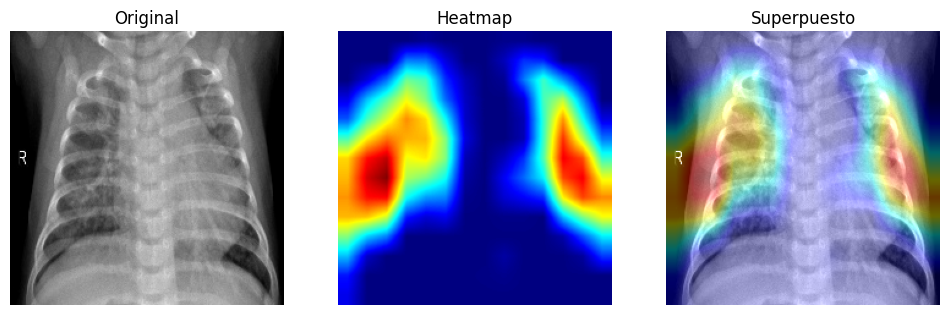

In [27]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# 1) Reconstruye tu base VGG16 y carga pesos en tu modelo completo
base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

model = Sequential([
    base,
    Flatten(name="flatten"),
    Dense(256, activation="relu", name="fc1"),
    Dropout(0.5, name="dropout"),
    Dense(3, activation="softmax", name="predictions")  # Ajusta "3" a tu n.º de clases
])
model.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
model.load_weights("best_vgg16.h5")


# 2) Nombre de la última capa conv y capa de pooling
last_conv_name = "block5_conv3"
pool_name      = "block5_pool"

# 3) Submodelo que va de input de VGG16 → salida de block5_conv3
last_conv_layer = base.get_layer(last_conv_name)
last_conv_model = tf.keras.Model(inputs=base.input,
                                 outputs=last_conv_layer.output)

# 4) Submodelo “clasificador” que va de salida de block5_conv3 → predicción final
#    Incluye la capa de pooling para que el flatten encaje con fc1
conv_shape = last_conv_layer.output.shape[1:]  # e.g. (14,14,512)
conv_input = Input(shape=conv_shape)

x = base.get_layer(pool_name)(conv_input)     # ahora (7,7,512)
x = Flatten()(x)                              # ahora vector 25088
x = model.get_layer("fc1")(x)
x = model.get_layer("dropout")(x, training=False)
output = model.get_layer("predictions")(x)

classifier_model = tf.keras.Model(inputs=conv_input,
                                  outputs=output)


# 5) Función Grad-CAM
def make_gradcam_heatmap(img_array, last_conv_model, classifier_model, pred_index=None):
    # 5.1 Paso conv
    conv_outputs = last_conv_model(img_array)              # (1,14,14,512)
    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)
        # 5.2 Paso por el clasificador
        preds = classifier_model(conv_outputs)             # (1,num_classes)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 5.3 Gradientes
    grads = tape.gradient(class_channel, conv_outputs)     # mismo shape que conv_outputs
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2)).numpy()

    conv_outputs = conv_outputs[0].numpy()                 # (14,14,512)
    # 5.4 Ponderar cada canal
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:,:,i] *= pooled_grads[i]

    # 5.5 Generar y normalizar heatmap
    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= heatmap.max()
    return heatmap


# 6) Superponer heatmap sobre la imagen original
def superimpose_heatmap(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    hm_resized = cv2.resize(np.uint8(255 * heatmap), (w, h))
    hm_color   = cv2.applyColorMap(hm_resized, cv2.COLORMAP_JET)
    hm_color   = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)

    overlay = hm_color * alpha + img
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return img, hm_color, overlay


# 7) Ejemplo de uso con una imagen del test set
BASE_DIR = "/workspace/data/classification_dataV4-4-test"
img_path = os.path.join(BASE_DIR, "test", "BACTERIAL", "person124_bacteria_592.jpeg")

# 8) Pre-procesado
img = image.load_img(img_path, target_size=(224,224))
x   = image.img_to_array(img) / 255.0
x   = np.expand_dims(x, axis=0)

# 9) Predicción + Grad-CAM
preds      = model.predict(x)
pred_index = np.argmax(preds[0])
heatmap    = make_gradcam_heatmap(x, last_conv_model, classifier_model, pred_index)

# 10) Mostrar resultados
orig, cmap, overlay = superimpose_heatmap(img_path, heatmap)
plt.figure(figsize=(12,4))
for i, (im, title) in enumerate(
        zip([orig, cmap, overlay], ["Original","Heatmap","Superpuesto"])):
    plt.subplot(1,3,i+1)
    plt.title(title); plt.axis("off")
    plt.imshow(im)
plt.show()
